Modelo de IA Discriminativa.

---

In [210]:
import pandas as pd
import seaborn as sns

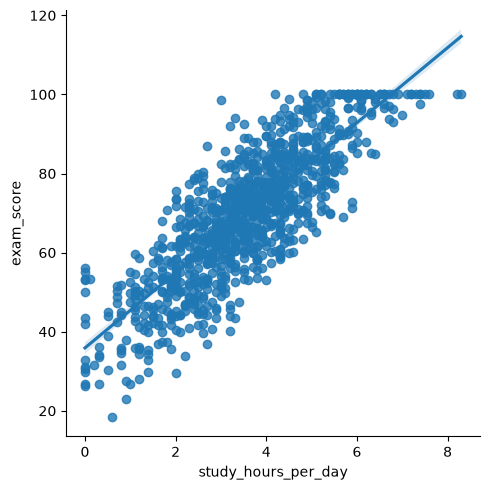

In [211]:
df = pd.read_csv(r"data\dados_tratados_estudantes.csv")
sns.lmplot(data = df, x = "study_hours_per_day", y = "exam_score");

Separando dados de entrada com os dados que serão descobertos.

In [249]:
X = df[["study_hours_per_day"]]
y = df["exam_score"]

Nesse caso será usado o modelo de Regressão Linear, para fazer uma previsão com o valor em questão.

In [250]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9.49]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['study_hours_per_day']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,35.91
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Foi feita a inserção de um aluno hipotético e as suas horas de estudo hipotéticas, e o resultado disso é com a função `.predict()`.

In [251]:
novo_aluno = pd.DataFrame({"study_hours_per_day" : [4]})

In [252]:
resultado = modelo.predict(novo_aluno)
print(resultado)

[73.87116366]


Usando o `.coef_`, é exibido o coeficiente angular.

In [ ]:
modelo.coef_

array([9.49025041])

Com o `intercept_`, é exibido o coeficiente linear.

In [ ]:
modelo.intercept_

np.float64(35.91016203402567)

O nível de confiança do modelo, medido através da função `.score()`. Por enquanto o modelo está com confiança de 68%, pois está somente trabalhando com um fator.

In [ ]:
modelo.score(X, y)

0.6813157156535874

---

Inserção dos outros fatores no modelo para conferir se o score de confiabilidade é alterado.

Foram inseridos todas as colunas possíveis (as que possuem dados numéricos) para o modelo fazer a análise.

In [281]:
X = df[["age", "study_hours_per_day", "social_media_hours", "netflix_hours", "attendance_percentage", "sleep_hours", "exercise_frequency", "mental_health_rating"]]

Novamente, é feito o comando para que o modelo faça o treinamento com esses dados.

In [282]:
modelo.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[-0.01, 9.57,-2.62,..., 2.01, 1.45, 1.95]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','study_hours_per_day','social_media_hours',...,'sleep_hours', 'exercise_frequency','mental_health_rating']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.451
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


Inserção do perfil do `novo_aluno`, para que sejam feitos os testes.

In [283]:
novo_aluno = pd.DataFrame({"age" : [24],
                           "study_hours_per_day" : [2],
                           "social_media_hours" : [2],
                           "netflix_hours" : [0],
                           "attendance_percentage" : [100],
                           "sleep_hours" : [8],
                           "exercise_frequency" : [5],
                           "mental_health_rating" : [10]})

Resultado que o aluno hipotético vai ter, usando o comando `.predict()`, com base no perfil dele.

In [284]:
resultado = modelo.predict(novo_aluno)
print(resultado)

[77.27317747]


Agora no `.coef_`, é exibido todos os coeficientes angulares de cada variável do dataset.

In [286]:
modelo.coef_

array([-0.01409257,  9.57468145, -2.62003173, -2.27709508,  0.14463401,
        2.0056268 ,  1.45179402,  1.94839335])

In [287]:
modelo.intercept_

np.float64(6.450780990020817)

Cálculo do score atual do modelo, agora com todas as variáveis númericas presentes nas colunas do dataset.

In [285]:
modelo.score(X, y)

0.9010746354967565

---

Foi feito o teste de inserir outros fatores(coeficientes) no modelo. Foram inseridos: `age`, `study_hours_per_day`, `social_media_hours`, `netflix_hours`, `attendance_percentage`,  `sleep_hours`, `exercise_frequency`, e `mental_health_rating`.<br>
Após alguns testes, foi feito o cálculo do score do modelo, agora o modelo tem 90% de confiabilidade, comparado ao primeiro teste que, com apenas 1 variável, tinha 68% de confiabilidade.